# Choosing the Latent Distribution in Flow Matching

A fundamental choice in flow matching is the source distribution from which we sample latent variables. While standard Gaussian noise is the default choice, the geometry and tail behavior of the target distribution may suggest alternative latent distributions.

## Key Question

**Can we improve flow matching by adapting the noise distribution componentwise to match the target geometry?**

In this notebook, we explore this question using Neal's funnel distribution, which exhibits different tail behaviors in each dimension. We'll compare three types of latent distributions:

1. **Uniform:** Bounded support, no tails
2. **Gaussian:** Light tails, standard choice
3. **Student-t:** Heavy tails, with componentwise adaptation



## Setup for Google Colab

In [19]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    print("Installing dependencies...")
    !pip install -q pot geomloss
    
    # Download fm_utils.py
    import urllib.request
    url = "https://raw.githubusercontent.com/JChemseddine/fm_tutorial/main/fm_utils.py"
    urllib.request.urlretrieve(url, "fm_utils.py")
    print("✓ Setup complete!")
else:
    # Local development - add parent directory to path
    import sys
    sys.path.insert(0, '..')

## Imports

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from geomloss import SamplesLoss

from fm_utils import (
    DEVICE,
    FlowConfig,
    compute_ema,
    draw_samples,
    euler_integrate,
    get_distribution,
    make_batch_sampler,
    make_latent_sampler,
    plot_funnel_with_marginals,
    plot_latent_colored_by_endpoint_norm,
    set_seed,
    train_flow,
)

# Define distance metric for comparing distributions
mmd_loss = SamplesLoss("energy")

# Configuration: Number of samples for visualization
n_samples = 500_000  # Number of samples for visualization plots

print(f"Using device: {DEVICE}")
print(f"Visualization samples: {n_samples:,}")

Using device: cuda
Visualization samples: 500,000


## Understanding Neal's Funnel

Neal's funnel is a hierarchical distribution with asymmetric tail behavior:

$$
\begin{align}
x_1 &\sim \mathcal{N}(0, \sigma_1^2) \\
x_2 | x_1 &\sim \mathcal{N}(0, e^{\alpha x_1})
\end{align}
$$

This creates:
- **Dimension 1 ($x_1$)**: Light-tailed Gaussian
- **Dimension 2 ($x_2$)**: Heavy-tailed (variance grows exponentially with $x_1$)

The key insight: **different dimensions have different tail behaviors**, suggesting that we should use different noise distributions per dimension.

### Z-Score Normalization for Stability

The funnel has extreme scale variations that can cause numerical instability. To handle this, we use **z-score normalization**:

$$\text{normalized}_i = \frac{x_i - \mu_i}{\sigma_i}$$

For the funnel:
- **$x_1$**: Mean 0, std $\sigma_1$ (e.g., 3.0)
- **$x_2$**: Mean 0, std $\approx \exp(0.25 \times \alpha^2 \times \sigma_1^2)$

The `ZScoreWrapper` in `fm_utils` applies this automatically, ensuring stable training while preserving the funnel's geometry.

**Why this matters:** Without normalization, $x_2$ can range from -1000 to +1000, making training very difficult.

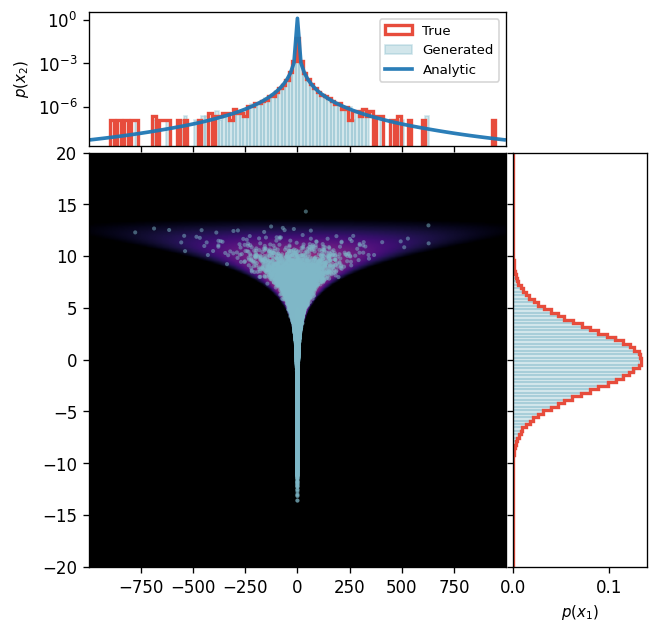

Notice: $x_2$ has much heavier tails than $x_1$


In [21]:
set_seed(42)

# Create Neal's funnel distribution
funnel = get_distribution("funnel", sigma1=3.0, alpha=1.0)
funnel_sampler = make_batch_sampler(funnel)
samples = draw_samples(funnel, n=n_samples)

# Visualize the funnel with marginals
fig = plot_funnel_with_marginals(
    samples, 
    funnel,
    title="Neal's Funnel Distribution"
)
plt.show()
plt.close(fig)

print("Notice: $x_2$ has much heavier tails than $x_1$")

## Training Configuration

We'll use the same training setup for all experiments to ensure fair comparison.

By default, we use random pairing between latent and target samples. You can optionally enable `pairing='minibatch_ot'` for structured optimal transport pairings.

In [22]:
# Base training configuration
base_config = {
    'target_sampler': funnel_sampler,
    'latent_sampler': None,  # Will set per experiment
    'pairing': 'none',
    'steps': 20_000,
    'batch_size': 128,
    'log_every': 1000,
    'lr': 2e-4,
    'seed': 42,
    'flow_T': 1.0,
    'ema_decay': 0.99
}


---

## Exploration 1: Uniform Latents

Let's start with **uniform distributions** which have bounded support and no tails. We use IID uniform with range [-2, 2] as our baseline.

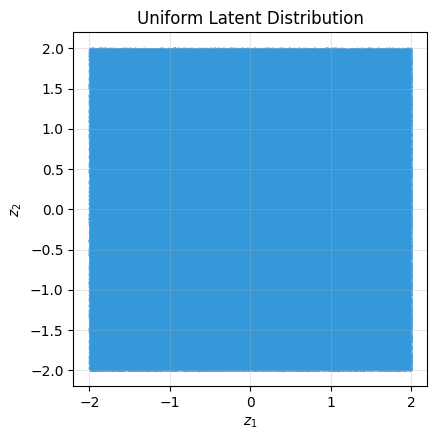

In [23]:
# Choose your latent sampler here:
latent_sampler_uniform = make_latent_sampler("uniform", DEVICE, 2)

# Visualize the latent distribution
latents = latent_sampler_uniform((n_samples, 2))
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(latents.cpu()[:, 0], latents.cpu()[:, 1], s=3, alpha=0.4, color='#3498DB', linewidths=0)
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
ax.set_title('Uniform Latent Distribution')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
print("Training with Uniform latents...")
print("=" * 60)

config_uniform = base_config.copy()
config_uniform['latent_sampler'] = latent_sampler_uniform

run_uniform = train_flow(FlowConfig(**config_uniform))

Training with Uniform latents...
step  1000 | loss = 18.642797
step  2000 | loss = 4.695938
step  3000 | loss = 2.456336
step  4000 | loss = 2.762276
step  5000 | loss = 2.248794
step  6000 | loss = 1.728950
step  7000 | loss = 3.860205
step  8000 | loss = 2.452180
step  9000 | loss = 2.347872
step 10000 | loss = 2.313803
step 11000 | loss = 2.239895
step 12000 | loss = 2.091986
step 13000 | loss = 3.223792
step 14000 | loss = 2.226474
step 15000 | loss = 2.327089
step 16000 | loss = 2.045608
step 17000 | loss = 2.640957
step 18000 | loss = 2.228926
step 19000 | loss = 2.468226
step 20000 | loss = 2.123612


In [ ]:
# Generate samples
latents = latent_sampler_uniform((n_samples, 2))
with torch.no_grad():
    generated_uniform = euler_integrate(run_uniform.ema, latents, run_uniform.config.flow_T, steps=150)

# Advanced funnel plot with marginals
fig = plot_funnel_with_marginals(
    generated_uniform, 
    funnel,
    title="Uniform Latents: Generated vs True Distribution"
)
plt.show()
plt.close(fig)

# Latent space analysis
# Each latent is colored by the norm of its corresponding generated sample (ODE integration endpoint)
fig = plot_latent_colored_by_endpoint_norm(
    latents,
    generated_uniform,
    title="Uniform: Latent colored by ||x|| (x = generated sample)",
    cmap='plasma'
)
plt.show()
plt.close(fig)

---

## Exploration 2: Gaussian Latents

Now let's try **Gaussian distributions** which have light tails. We use standard IID Gaussian (mean=0, std=1) - the most common choice in flow matching.

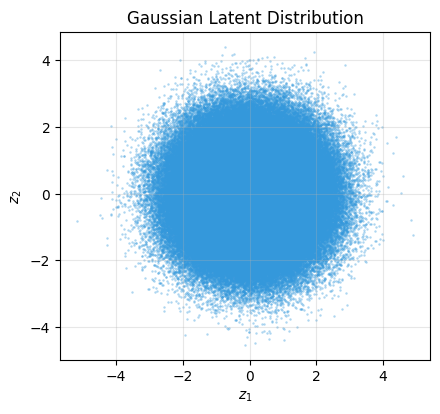

In [27]:
# Choose your latent sampler here:
latent_sampler_gaussian = make_latent_sampler("gaussian", DEVICE, 2)

# Visualize the latent distribution
latents = latent_sampler_gaussian((n_samples, 2))
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(latents.cpu()[:, 0], latents.cpu()[:, 1], s=3, alpha=0.4, color='#3498DB', linewidths=0)
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
ax.set_title('Gaussian Latent Distribution')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
print("Training with Gaussian latents...")
print("=" * 60)

config_gaussian = base_config.copy()
config_gaussian['latent_sampler'] = latent_sampler_gaussian

run_gaussian = train_flow(FlowConfig(**config_gaussian))

Training with Gaussian latents...
step  1000 | loss = 16.500286
step  2000 | loss = 4.069989
step  3000 | loss = 1.632719
step  4000 | loss = 2.836816
step  5000 | loss = 2.385687
step  6000 | loss = 1.662579
step  7000 | loss = 3.734273
step  8000 | loss = 2.581397
step  9000 | loss = 2.341839
step 10000 | loss = 1.900268
step 11000 | loss = 1.755785
step 12000 | loss = 2.080848
step 13000 | loss = 2.464769
step 14000 | loss = 2.186614
step 15000 | loss = 2.058645
step 16000 | loss = 1.982828
step 17000 | loss = 2.119633
step 18000 | loss = 1.762844
step 19000 | loss = 2.313327
step 20000 | loss = 2.122011


In [ ]:

# Generate samples
latents = latent_sampler_gaussian((n_samples, 2))
with torch.no_grad():
    generated_gaussian = euler_integrate(run_gaussian.ema, latents, run_gaussian.config.flow_T, steps=150)

# Advanced funnel plot with marginals
fig = plot_funnel_with_marginals(
    generated_gaussian, 
    funnel,
    title="Gaussian Latents: Generated vs True Distribution"
)
plt.show()
plt.close(fig)

# Latent space analysis
# Each latent is colored by the norm of its corresponding generated sample (ODE integration endpoint)
fig = plot_latent_colored_by_endpoint_norm(
    latents,
    generated_gaussian,
    title="Gaussian: Latent colored by ||x|| (x = generated sample)",
    cmap='plasma'
)
plt.show()
plt.close(fig)

---

## Exploration 3: Student-t Latents (Componentwise Adaptation)

### Mathematical Definition

The **Student-t distribution** with degrees of freedom $\nu$ and scale $\sigma$ has probability density:

$$p(x) \propto \left(1 + \frac{x^2}{\nu \sigma^2}\right)^{-\frac{\nu+1}{2}}$$

The **degrees of freedom** $\nu$ controls tail behavior:
- $\nu \to \infty$: Converges to Gaussian $\mathcal{N}(0, \sigma^2)$ (light tails)
- Small $\nu$ (e.g., $\nu=4$): Heavy tails with $\mathbb{P}(|X| > t) \sim t^{-\nu}$

**Intuition:** Lower degrees of freedom allocate more probability mass to extreme values, making rare events more likely.



In [ ]:
# 🎯 YOUR TURN: Experiment with Student-t configurations!
# 
# Try different degrees of freedom (df) to match the funnel's tail behavior.
# Lower df = heavier tails, Higher df = lighter tails (approaches Gaussian)
#
# Some suggestions to try:
# - Symmetric: df=10 for both dimensions
# - Asymmetric: df=20 for x1 (light), df=4 for x2 (heavy)
# - Extreme: df=100 for x1 (very light), df=2 for x2 (very heavy)

latent_sampler_studentt = make_latent_sampler([
    ("student_t", {"df": 10, "scale": 1}),  # Adjust df for x1
    ("student_t", {"df": 10, "scale": 1})   # Adjust df for x2
], DEVICE, 2)

# Visualize the latent distribution
latents = latent_sampler_studentt((n_samples, 2))
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(latents.cpu()[:, 0], latents.cpu()[:, 1], s=3, alpha=0.4, color='#3498DB', linewidths=0)
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
ax.set_title('Student-t Latent Distribution')
ax.set_aspect('equal','box')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Experiment with different df values and observe how the tail behavior changes!")

In [32]:
print("Training with Student-t latents (componentwise adaptation)...")
print("=" * 60)

config_studentt = base_config.copy()
config_studentt['latent_sampler'] = latent_sampler_studentt

run_studentt = train_flow(FlowConfig(**config_studentt))

Training with Student-t latents (componentwise adaptation)...
step  1000 | loss = 3.840793
step  2000 | loss = 3.221311
step  3000 | loss = 3.343723
step  4000 | loss = 2.598309
step  5000 | loss = 2.508228
step  6000 | loss = 3.103416
step  7000 | loss = 2.556262
step  8000 | loss = 2.513198
step  9000 | loss = 12.141092
step 10000 | loss = 2.312309
step 11000 | loss = 2.110543
step 12000 | loss = 2.037942
step 13000 | loss = 3.585198
step 14000 | loss = 2.296732
step 15000 | loss = 2.836508
step 16000 | loss = 6.494337
step 17000 | loss = 3.811201
step 18000 | loss = 1.831790
step 19000 | loss = 3.140271
step 20000 | loss = 3.064515


In [ ]:
# Generate samples
latents = latent_sampler_studentt((n_samples, 2))
with torch.no_grad():
    generated_studentt = euler_integrate(run_studentt.ema, latents, run_studentt.config.flow_T, steps=150)

# Advanced funnel plot with marginals
fig = plot_funnel_with_marginals(
    generated_studentt, 
    funnel,
    title="Student-t (Non-IID): Generated vs True Distribution"
)
plt.show()
plt.close(fig)

# Latent space analysis
# Each latent is colored by the norm of its corresponding generated sample (ODE integration endpoint)
fig = plot_latent_colored_by_endpoint_norm(
    latents,
    generated_studentt,
    title="Student-t: Latent colored by ||x|| (x = generated sample)",
    cmap='plasma'
)
plt.show()
plt.close(fig)

---

## Comparison: Does Componentwise Adaptation Help?

Let's compare all three approaches to see which one works best for the funnel distribution.

In [ ]:
# Compare all three approaches with detailed funnel plots
for name, generated, color in [
    ("Uniform Latents", generated_uniform, '#E74C3C'),
    ("Gaussian Latents", generated_gaussian, '#3498DB'),
    ("Student-t (Non-IID)", generated_studentt, '#2ECC71')
]:
    print(f"\n{name}")
    print("-" * 50)
    fig = plot_funnel_with_marginals(
        generated,
        funnel,
        title=f"{name}: Generated vs True Distribution"
    )
    plt.show()
    plt.close(fig)

## Why Do Tails Matter?

**Key Questions to Consider:**

- Why might matching the tail behavior between latent and target distributions matter?
- What does it imply for the velocity field when tails don't match? When they do match?

### Next: Optimal Transport Pairing

So far we've used random pairing between latent and target samples. In the next notebook, we'll explore **minibatch optimal transport** to create structured pairings that can further improve learning.